In [2]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt

mesures = pd.read_csv("../data/mesures_synthetiques.csv", parse_dates=["timestamp"])
site_1 = mesures[mesures["site_id"] == 1].set_index("timestamp")["valeur_kwh"]
site_1 = site_1.asfreq("h")  # force une fréquence horaire explicite et régulière

print("Valeurs manquantes après asfreq :", site_1.isna().sum())

Valeurs manquantes après asfreq : 0


In [3]:
horizon_test = 24 * 14  # 2 semaines en heures
train = site_1.iloc[:-horizon_test]
test = site_1.iloc[-horizon_test:]

modele = ExponentialSmoothing(
    train, trend="add", seasonal="add", seasonal_periods=24
).fit()

previsions = modele.forecast(horizon_test)

In [4]:
mae = (test - previsions).abs().mean()
mape = ((test - previsions).abs() / test).mean() * 100

print(f"MAE : {mae:.3f} kWh")
print(f"MAPE : {mape:.2f}%")

MAE : 0.359 kWh
MAPE : 38.15%


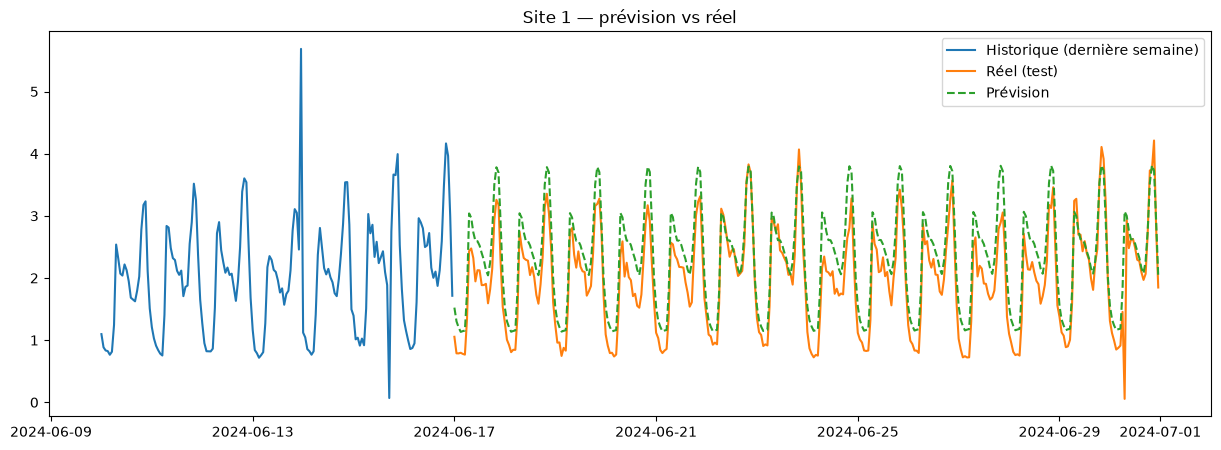

In [5]:
plt.figure(figsize=(15, 5))
plt.plot(train.index[-24*7:], train.iloc[-24*7:], label="Historique (dernière semaine)")
plt.plot(test.index, test, label="Réel (test)")
plt.plot(test.index, previsions, label="Prévision", linestyle="--")
plt.legend()
plt.title("Site 1 — prévision vs réel")
plt.show()

In [6]:
# Récupérer les anomalies détectées du site 1 depuis le CSV de vérité terrain
# (on utilise la vérité terrain ici pour l'exploration ; en production, on utiliserait la table `anomalies` de la base)
verite = pd.read_csv("../data/anomalies_verite_terrain.csv", parse_dates=["timestamp"])
anomalies_site_1 = verite[verite["site_id"] == 1]["timestamp"]

site_1_nettoye = site_1.copy()
site_1_nettoye.loc[anomalies_site_1] = None
site_1_nettoye = site_1_nettoye.interpolate(method="time")

train_nettoye = site_1_nettoye.iloc[:-horizon_test]

modele_nettoye = ExponentialSmoothing(
    train_nettoye, trend="add", seasonal="add", seasonal_periods=24
).fit()
previsions_nettoyees = modele_nettoye.forecast(horizon_test)

mae_nettoye = (test - previsions_nettoyees).abs().mean()
mape_nettoye = ((test - previsions_nettoyees).abs() / test).mean() * 100

print(f"MAE (nettoyé) : {mae_nettoye:.3f} kWh")
print(f"MAPE (nettoyé) : {mape_nettoye:.2f}%")

MAE (nettoyé) : 0.341 kWh
MAPE (nettoyé) : 36.82%


In [7]:
erreurs = (previsions_nettoyees - test)  # signé : positif = surestimation
erreurs_par_heure = erreurs.groupby(erreurs.index.hour).mean()
print(erreurs_par_heure)

0     0.316869
1     0.310572
2     0.281589
3     0.314939
4     0.298371
5     0.315562
6     0.336287
7     0.508619
8     0.286348
9     0.339783
10    0.268824
11    0.331135
12    0.291143
13    0.310079
14    0.265054
15    0.312175
16    0.298370
17    0.351297
18    0.363985
19    0.325848
20    0.388760
21    0.314702
22    0.310345
23    0.265411
dtype: float64


In [9]:
print("Dernier niveau estimé :", modele_nettoye.level.iloc[-1])
print("Dernière tendance estimée :", modele_nettoye.trend.iloc[-1])

Dernier niveau estimé : 2.2824132844808958
Dernière tendance estimée : 8.856831130732255e-05


In [10]:
# Moyenne des 48 dernières heures avant la coupure, vs moyenne globale du train
print("Moyenne des 48h juste avant le test :", train_nettoye.iloc[-48:].mean())
print("Moyenne globale de l'entraînement :", train_nettoye.mean())

Moyenne des 48h juste avant le test : 2.2161979166666668
Moyenne globale de l'entraînement : 2.0011927083333334


In [11]:
horizon_test = 24 * 14
nb_splits = 4
resultats_backtest = []

for i in range(nb_splits):
    fin_train = len(site_1_nettoye) - horizon_test * (i + 1)
    debut_test = fin_train
    fin_test = fin_train + horizon_test

    train_split = site_1_nettoye.iloc[:fin_train]
    test_split = site_1_nettoye.iloc[debut_test:fin_test]

    modele_split = ExponentialSmoothing(
        train_split, trend="add", seasonal="add", seasonal_periods=24
    ).fit()
    prevision_split = modele_split.forecast(horizon_test)

    mae_split = (test_split - prevision_split).abs().mean()
    mape_split = ((test_split - prevision_split).abs() / test_split).mean() * 100

    resultats_backtest.append({"split": i, "mae": mae_split, "mape": mape_split})

df_backtest = pd.DataFrame(resultats_backtest)
print(df_backtest)
print("\nMoyenne MAE :", df_backtest["mae"].mean())
print("Moyenne MAPE :", df_backtest["mape"].mean())

   split       mae       mape
0      0  0.335004  20.734408
1      1  0.387698  24.420561
2      2  0.251325  15.029051
3      3  0.348355  21.761015

Moyenne MAE : 0.33059568298863934
Moyenne MAPE : 20.486258733756188
